In [1]:
import sys, json, warnings
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.config import GROUNDTRUTH_DIR, PREDICTIONS_DIR, IMAGES_DIR
from src.evaluation.evaluate import (
    load_prediction, get_available_models, estrai_basi, normalizza_valori
)
from src.evaluation.rms import compute_rms

sns.set_style('ticks')
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333333', 'axes.linewidth': 0.8,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 8, 'legend.frameon': True,
    'legend.framealpha': 0.9, 'legend.edgecolor': '#cccccc',
    'font.size': 9, 'grid.linewidth': 0.5, 'grid.color': '#dddddd',
})
print('Librerie caricate.')

Librerie caricate.


In [2]:
_DEPLOT_SUPPORTED = frozenset({'bar', 'line', 'pie'})
DATASETS = ['arXiv', 'PMCharts']


def collect_records(datasets=DATASETS, models=None):
    """Raccoglie per ogni file GT x modello: n_datapoints, n_series, f1."""
    if models is None:
        models = get_available_models()

    records = []
    for ds_idx, dataset in enumerate(datasets):
        img_base_dir = IMAGES_DIR / dataset
        if not img_base_dir.exists():
            print(f'  Skip: {img_base_dir} non trovata')
            continue
        chart_classes = sorted([d.name for d in img_base_dir.iterdir() if d.is_dir()])
        print(f'[{ds_idx+1}/{len(datasets)}] {dataset}: {chart_classes}')

        for chart_class in chart_classes:
            gt_dir = GROUNDTRUTH_DIR / dataset / chart_class
            if not gt_dir.exists():
                continue
            gt_files = sorted(gt_dir.rglob('*.json'))
            print(f'  {chart_class}: {len(gt_files)} file GT', end='')

            for gt_file in gt_files:
                try:
                    with open(gt_file, 'r', encoding='utf-8') as f:
                        gt_data = json.load(f)
                except Exception:
                    continue

                pts = gt_data.get('data_points', [])
                n_datapoints = len(pts)

                if chart_class == 'heatmap' or not pts or 'series_name' not in pts[0]:
                    n_series = np.nan
                else:
                    n_series = len({p.get('series_name', '') for p in pts})

                basi_gt = estrai_basi(gt_data)
                gt_data_norm = normalizza_valori(gt_data, basi_gt)

                for model in models:
                    is_deplot = model.lower() == 'deplot'

                    if is_deplot and chart_class not in _DEPLOT_SUPPORTED:
                        records.append({
                            'model': model, 'dataset': dataset,
                            'chart_class': chart_class, 'filename': gt_file.name,
                            'n_datapoints': n_datapoints, 'n_series': n_series, 'f1': 0.0,
                        })
                        continue

                    pred_dir = PREDICTIONS_DIR / model / dataset / chart_class
                    pred_file = pred_dir / gt_file.relative_to(gt_dir)
                    pred_data = load_prediction(pred_file, basi_gt)

                    if pred_data is None:
                        f1 = 0.0
                    else:
                        try:
                            result = compute_rms(
                                pred_data, gt_data_norm,
                                chart_type=chart_class, try_transpose=is_deplot
                            )
                            f1 = result['f1'] * 100
                        except Exception:
                            f1 = 0.0

                    records.append({
                        'model': model, 'dataset': dataset,
                        'chart_class': chart_class, 'filename': gt_file.name,
                        'n_datapoints': n_datapoints, 'n_series': n_series, 'f1': f1,
                    })
            print(' ✓')

    return pd.DataFrame(records)

In [3]:
warnings.filterwarnings('ignore')
print('Raccolta dati in corso (qualche minuto)...')
df = collect_records()
warnings.filterwarnings('default')

modelli = df['model'].unique().tolist()
ds_list = df['dataset'].unique().tolist()
cc_list = sorted(df['chart_class'].unique().tolist())
print(f'Record totali : {len(df)}')
print(f'Modelli       : {modelli}')
print(f'Dataset       : {ds_list}')
print(f'Chart classes : {cc_list}')

Raccolta dati in corso (qualche minuto)...
[1/2] arXiv: ['bar', 'box', 'errorpoint', 'heatmap', 'histogram', 'line', 'pie', 'radar', 'scatter']
  bar: 50 file GT

 ✓
  box: 50 file GT

 ✓
  errorpoint: 50 file GT

 ✓
  heatmap: 50 file GT

 ✓
  histogram: 50 file GT

...

 ✓
  line: 50 file GT

 ✓
  pie: 50 file GT

 ✓
  radar: 50 file GT

 ✓
  scatter: 50 file GT

 ✓
Record totali : 7600
Modelli       : ['DePlot', 'InternVL2.5-2B', 'Phi3.5-Vision', 'Qwen2B', 'claude-sonnet-4-5', 'gemini-2.5-flash', 'gpt-4o', 'gpt-4o-mini']
Dataset       : ['arXiv', 'PMCharts']
Chart classes : ['bar', 'box', 'bubble', 'errorpoint', 'heatmap', 'histogram', 'line', 'pie', 'radar', 'scatter']


In [4]:
df.describe().round(2)

,n_datapoints,n_series,f1
count,7600.00,6800.00,7600.00
mean,15.73,1.86,41.30
std,12.60,1.27,37.63
min,1.00,1.00,0.00
25%,6.00,1.00,2.21
50%,12.00,1.00,31.71
75%,21.00,2.00,78.59
max,85.00,11.00,100.00


In [5]:
pivot_mean = (
    df.groupby(['model', 'chart_class'])['f1']
    .mean().unstack().round(1)
)
display(pivot_mean)

models_sorted = sorted(df['model'].unique())
palette = sns.color_palette('tab10', len(models_sorted))
color_map = dict(zip(models_sorted, palette))

chart_class,bar,box,bubble,errorpoint,heatmap,histogram,line,pie,radar,scatter
model,,,,,,,,,,
DePlot,61.8,0.0,0.0,0.0,0.0,0.0,48.4,37.5,0.0,0.0
InternVL2.5-2B,34.3,3.5,2.4,13.0,15.6,21.7,26.0,46.0,10.3,14.2
Phi3.5-Vision,38.7,41.1,7.8,30.2,55.2,26.5,26.4,51.6,18.0,22.9
Qwen2B,22.5,13.1,7.1,9.5,36.8,15.3,15.9,31.9,4.8,11.5
claude-sonnet-4-5,87.7,79.8,51.8,64.7,87.5,61.5,79.8,83.5,37.8,65.8
gemini-2.5-flash,93.8,94.5,61.9,83.4,84.9,64.7,91.4,96.4,45.7,76.6
gpt-4o,67.8,60.0,33.8,54.0,80.1,42.3,54.5,83.7,31.1,38.6
gpt-4o-mini,39.2,36.7,17.2,28.3,69.3,33.0,28.0,70.3,22.4,24.8


In [6]:
def corr_summary(data, x_col, y_col='f1', group_col='model'):
    rows = []
    for name, grp in data.dropna(subset=[x_col, y_col]).groupby(group_col):
        if len(grp) < 5:
            continue
        r_p, p_p = stats.pearsonr(grp[x_col], grp[y_col])
        r_s, p_s = stats.spearmanr(grp[x_col], grp[y_col])
        rows.append({
            group_col: name,
            'pearson_r': round(r_p, 3), 'pearson_p': round(p_p, 4),
            'spearman_r': round(r_s, 3), 'spearman_p': round(p_s, 4),
            'n': len(grp),
        })
    return pd.DataFrame(rows).set_index(group_col)

## F1 vs numero di data point

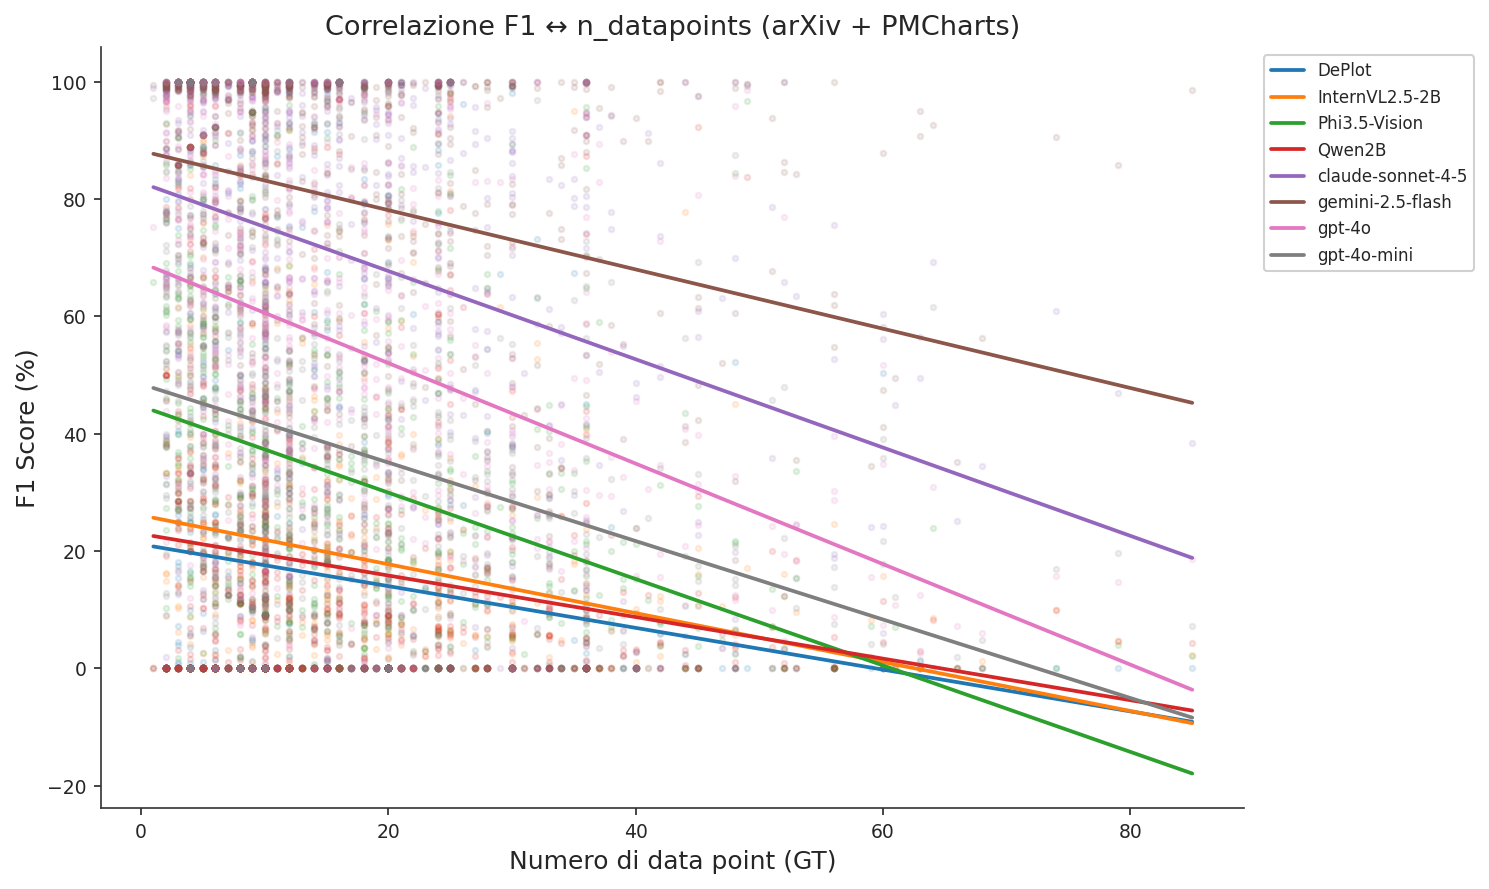


--- Pearson & Spearman r (F1 vs n_datapoints) per modello ---


,pearson_r,pearson_p,spearman_r,spearman_p,n
model,,,,,
DePlot,-0.144,0.0,-0.170,0.0000,950
InternVL2.5-2B,-0.189,0.0,-0.090,0.0054,950
Phi3.5-Vision,-0.316,0.0,-0.341,0.0000,950
Qwen2B,-0.180,0.0,-0.117,0.0003,950
claude-sonnet-4-5,-0.290,0.0,-0.290,0.0000,950
gemini-2.5-flash,-0.231,0.0,-0.309,0.0000,950
gpt-4o,-0.347,0.0,-0.359,0.0000,950
gpt-4o-mini,-0.277,0.0,-0.321,0.0000,950


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

for model in models_sorted:
    grp = df[df['model'] == model]
    ax.scatter(grp['n_datapoints'], grp['f1'],
               alpha=0.12, s=7, color=color_map[model])
    if len(grp) > 5:
        m_r, b_r = np.polyfit(grp['n_datapoints'], grp['f1'], 1)
        x_r = np.linspace(grp['n_datapoints'].min(), grp['n_datapoints'].max(), 100)
        ax.plot(x_r, m_r * x_r + b_r, color=color_map[model], linewidth=1.8, label=model)

ax.set_xlabel('Numero di data point (GT)', fontsize=12)
ax.set_ylabel('F1 Score (%)', fontsize=12)
ax.set_title('Correlazione F1 ↔ n_datapoints (arXiv + PMCharts)', fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print('\n--- Pearson & Spearman r (F1 vs n_datapoints) per modello ---')
display(corr_summary(df, 'n_datapoints'))

## F1 vs numero di serie

/home/giorgiomelch/miniconda3/envs/checkct/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


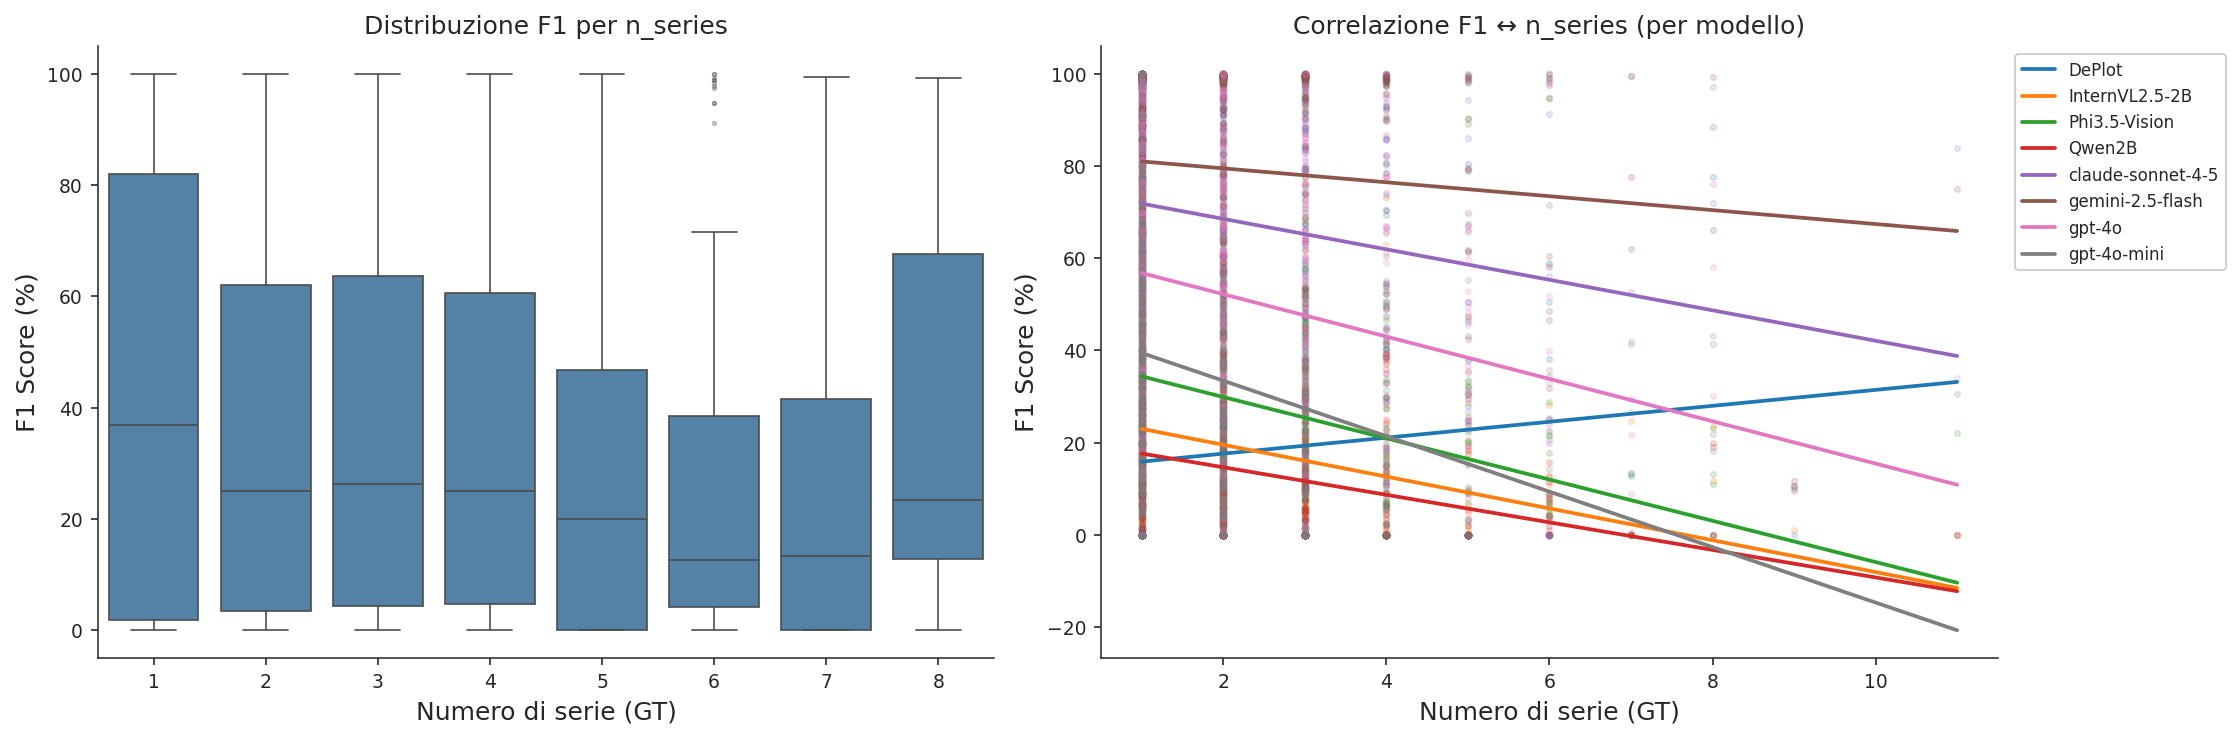


--- Pearson & Spearman r (F1 vs n_series) per modello ---


,pearson_r,pearson_p,spearman_r,spearman_p,n
model,,,,,
DePlot,0.068,0.0486,0.095,0.0058,850
InternVL2.5-2B,-0.160,0.0000,-0.074,0.0313,850
Phi3.5-Vision,-0.213,0.0000,-0.202,0.0000,850
Qwen2B,-0.178,0.0000,-0.144,0.0000,850
claude-sonnet-4-5,-0.129,0.0002,-0.147,0.0000,850
gemini-2.5-flash,-0.070,0.0421,-0.092,0.0070,850
gpt-4o,-0.196,0.0000,-0.207,0.0000,850
gpt-4o-mini,-0.280,0.0000,-0.353,0.0000,850


In [8]:
df_s = df.dropna(subset=['n_series']).copy()
df_s['n_series'] = df_s['n_series'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_ns = sorted(df_s['n_series'].value_counts().nlargest(8).index.tolist())
sns.boxplot(
    data=df_s[df_s['n_series'].isin(top_ns)],
    x='n_series', y='f1', order=top_ns,
    color='steelblue', linewidth=0.8,
    flierprops=dict(marker='.', markersize=3, alpha=0.4),
    ax=axes[0],
)
axes[0].set_xlabel('Numero di serie (GT)', fontsize=12)
axes[0].set_ylabel('F1 Score (%)', fontsize=12)
axes[0].set_title('Distribuzione F1 per n_series', fontsize=12)
sns.despine(ax=axes[0])

for model in models_sorted:
    grp = df_s[df_s['model'] == model]
    axes[1].scatter(grp['n_series'], grp['f1'],
                    alpha=0.15, s=7, color=color_map[model])
    if len(grp) > 5:
        m_r, b_r = np.polyfit(grp['n_series'], grp['f1'], 1)
        x_r = np.linspace(grp['n_series'].min(), grp['n_series'].max(), 50)
        axes[1].plot(x_r, m_r * x_r + b_r, color=color_map[model], linewidth=1.8, label=model)

axes[1].set_xlabel('Numero di serie (GT)', fontsize=12)
axes[1].set_ylabel('F1 Score (%)', fontsize=12)
axes[1].set_title('Correlazione F1 ↔ n_series (per modello)', fontsize=12)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print('\n--- Pearson & Spearman r (F1 vs n_series) per modello ---')
display(corr_summary(df_s, 'n_series'))

## Heatmap correlazione Spearman per chart class × modello

/tmp/ipykernel_47386/2950306410.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = np.nan if len(grp) < 5 else round(stats.spearmanr(grp[x_col], grp[y_col])[0], 2)
/tmp/ipykernel_47386/2950306410.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = np.nan if len(grp) < 5 else round(stats.spearmanr(grp[x_col], grp[y_col])[0], 2)


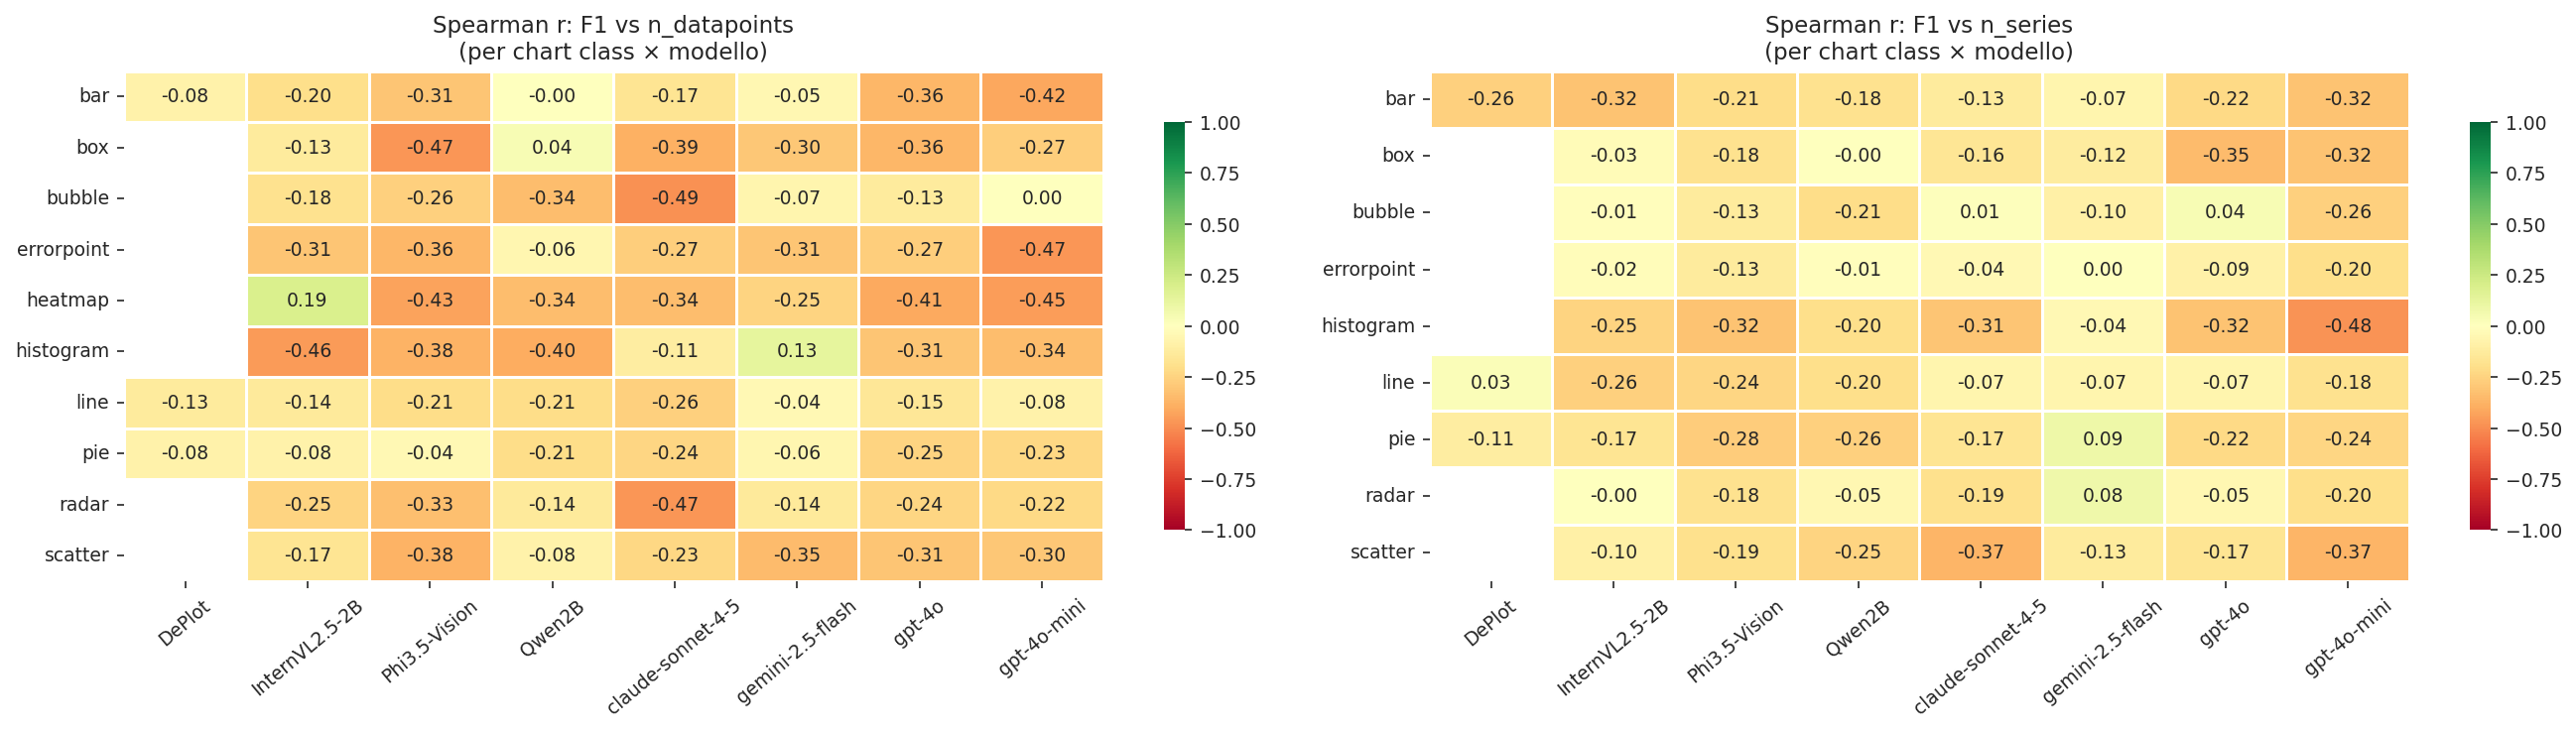

In [9]:
def spearman_pivot(data, x_col, y_col='f1'):
    rows = {}
    for (cc, model), grp in data.dropna(subset=[x_col, y_col]).groupby(['chart_class', 'model']):
        r = np.nan if len(grp) < 5 else round(stats.spearmanr(grp[x_col], grp[y_col])[0], 2)
        rows.setdefault(cc, {})[model] = r
    return pd.DataFrame(rows).T


fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, (x_col, data, title) in zip(axes, [
    ('n_datapoints', df,   'Spearman r: F1 vs n_datapoints'),
    ('n_series',     df_s, 'Spearman r: F1 vs n_series'),
]):
    pivot = spearman_pivot(data, x_col)
    sns.heatmap(
        pivot, annot=True, fmt='.2f', cmap='RdYlGn',
        center=0, vmin=-1, vmax=1, linewidths=0.5,
        ax=ax, cbar_kws={'shrink': 0.8},
    )
    ax.set_title(f'{title}\n(per chart class × modello)', fontsize=11)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

## Faceted scatter F1 vs n_datapoints per chart class

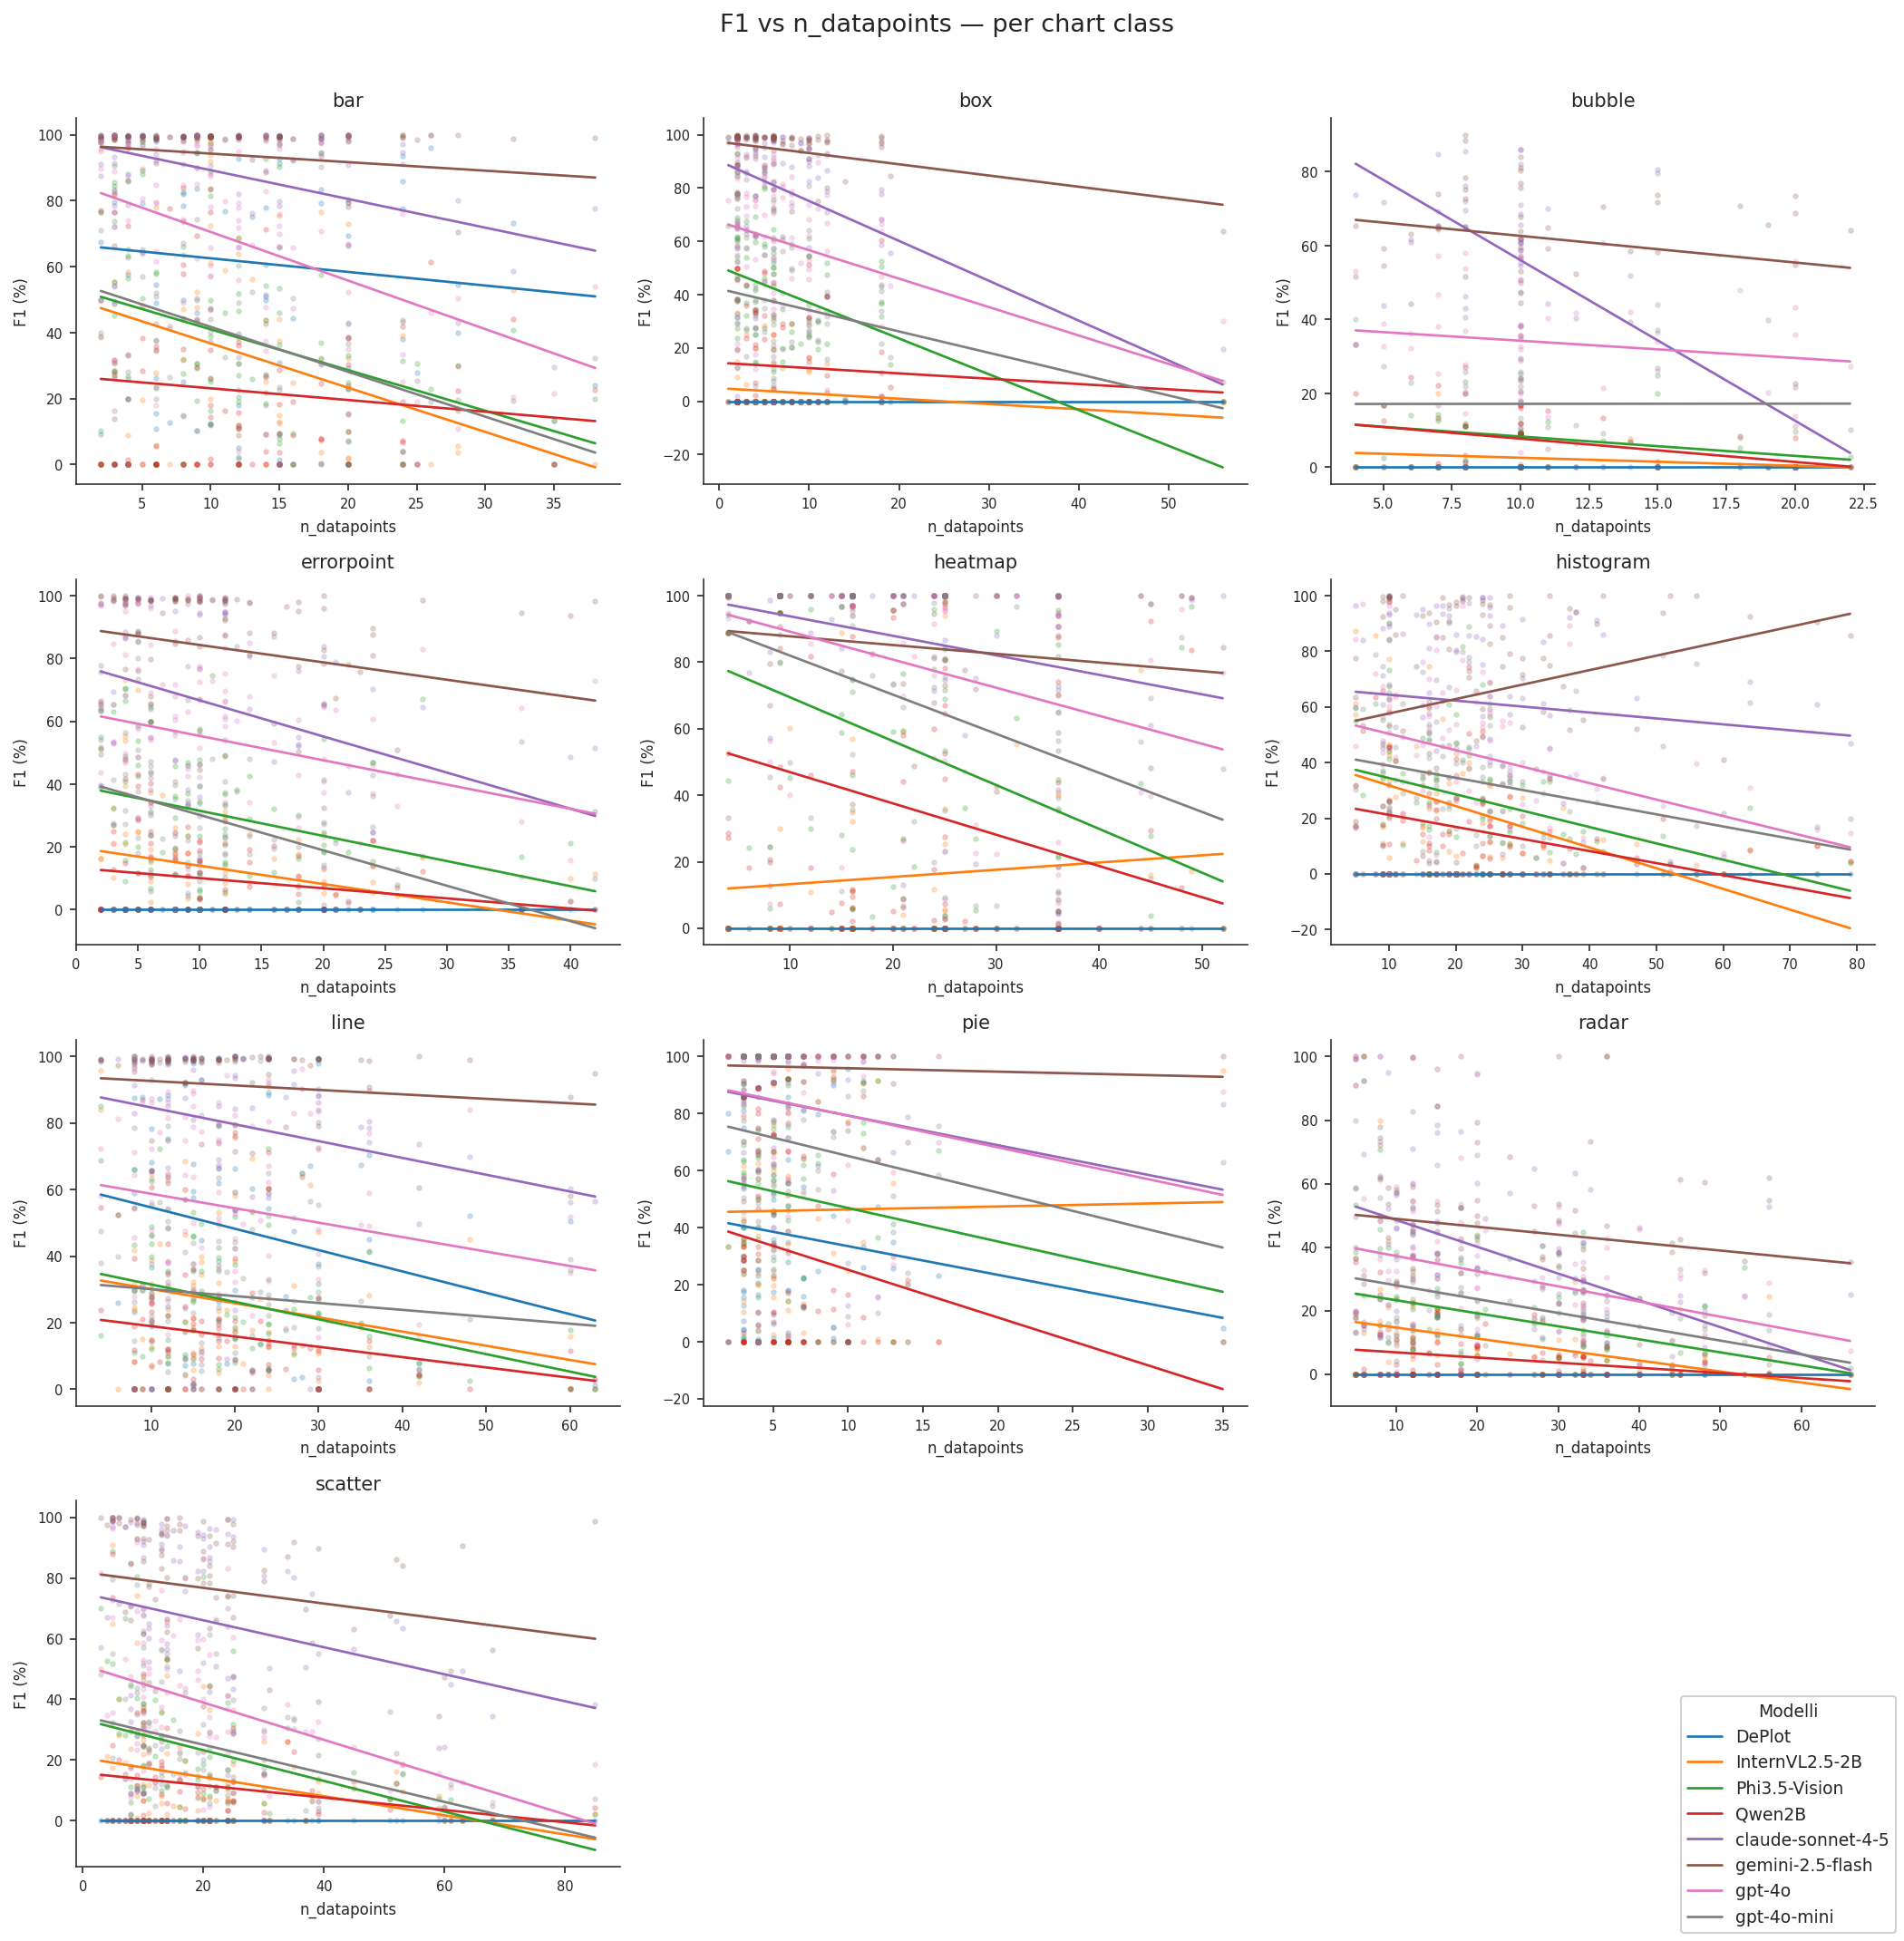

In [10]:
chart_classes = sorted(df['chart_class'].unique())
n_cols = 3
n_rows = (len(chart_classes) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, cc in enumerate(chart_classes):
    ax = axes[i]
    grp_cc = df[df['chart_class'] == cc]
    for model in models_sorted:
        grp = grp_cc[grp_cc['model'] == model]
        ax.scatter(grp['n_datapoints'], grp['f1'],
                   alpha=0.2, s=5, color=color_map[model])
        if len(grp) > 3:
            m_r, b_r = np.polyfit(grp['n_datapoints'], grp['f1'], 1)
            x_r = np.linspace(grp['n_datapoints'].min(), grp['n_datapoints'].max(), 50)
            ax.plot(x_r, m_r * x_r + b_r, color=color_map[model],
                    linewidth=1.3, label=model)
    ax.set_title(cc, fontsize=10)
    ax.set_xlabel('n_datapoints', fontsize=8)
    ax.set_ylabel('F1 (%)', fontsize=8)
    ax.tick_params(labelsize=7)
    sns.despine(ax=ax)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=9, title='Modelli', title_fontsize=9)
fig.suptitle('F1 vs n_datapoints — per chart class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Tabella riassuntiva correlazioni

In [11]:
rows = []
for x_col, data in [('n_datapoints', df), ('n_series', df_s)]:
    tbl = corr_summary(data, x_col).copy()
    tbl.insert(0, 'metrica', x_col)
    rows.append(tbl)

summary = pd.concat(rows).reset_index()
summary = summary.sort_values(['metrica', 'model'])
display(summary.set_index(['metrica', 'model']))

pearson_r  pearson_p  spearman_r  spearman_p  \
metrica      model                                                             
n_datapoints DePlot                -0.144     0.0000      -0.170      0.0000   
             InternVL2.5-2B        -0.189     0.0000      -0.090      0.0054   
             Phi3.5-Vision         -0.316     0.0000      -0.341      0.0000   
             Qwen2B                -0.180     0.0000      -0.117      0.0003   
             claude-sonnet-4-5     -0.290     0.0000      -0.290      0.0000   
             gemini-2.5-flash      -0.231     0.0000      -0.309      0.0000   
             gpt-4o                -0.347     0.0000      -0.359      0.0000   
             gpt-4o-mini           -0.277     0.0000      -0.321      0.0000   
n_series     DePlot                 0.068     0.0486       0.095      0.0058   
             InternVL2.5-2B        -0.160     0.0000      -0.074      0.0313   
             Phi3.5-Vision         -0.213     0.0000      -0.202      0.0000   
             Qwen2B                -0.178     0.0000      -0.144      0.0000   
             claude-sonnet-4-5     -0.129     0.0002      -0.147      0.0000   
             gemini-2.5-flash      -0.070     0.0421      -0.092      0.0070   
             gpt-4o                -0.196     0.0000      -0.207      0.0000   
             gpt-4o-mini           -0.280     0.0000      -0.353      0.0000   

                                  n  
metrica      model                   
n_datapoints DePlot             950  
             InternVL2.5-2B     950  
             Phi3.5-Vision      950  
             Qwen2B             950  
             claude-sonnet-4-5  950  
             gemini-2.5-flash   950  
             gpt-4o             950  
             gpt-4o-mini        950  
n_series     DePlot             850  
             InternVL2.5-2B     850  
             Phi3.5-Vision      850  
             Qwen2B             850  
             claude-sonnet-4-5  850  
             gemini-2.5-flash   850  
             gpt-4o             850  
             gpt-4o-mini        850